In [1]:
import pandas as pd

trader = pd.read_csv("trader_data.csv")
fg = pd.read_csv("fear_greed.csv")

print("TRADER columns:", trader.columns.tolist())
print("\nFEAR/GREED columns:", fg.columns.tolist())
print("\nTrader sample:\n", trader.head(3))
print("\nFear/Greed sample:\n", fg.head(3))

TRADER columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

FEAR/GREED columns: ['timestamp', 'value', 'classification', 'date']

Trader sample:
                                       Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0      

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

trader = pd.read_csv("trader_data.csv")
fg = pd.read_csv("fear_greed.csv")

print(f"Trader rows: {len(trader):,}")
print(f"Fear/Greed rows: {len(fg):,}")

Trader rows: 211,224
Fear/Greed rows: 2,644


In [3]:
# Fix date columns
trader["date"] = pd.to_datetime(trader["Timestamp IST"], dayfirst=True).dt.normalize()
fg["date"]     = pd.to_datetime(fg["date"]).dt.normalize()

# Merge on date
merged = trader.merge(fg[["date", "classification", "value"]], on="date", how="left")

# Sentiment bucket
def bucket(c):
    c = str(c).lower()
    if "fear"  in c: return "Fear"
    if "greed" in c: return "Greed"
    return "Neutral"

merged["sentiment"]  = merged["classification"].apply(bucket)
merged["Closed PnL"] = pd.to_numeric(merged["Closed PnL"], errors="coerce").fillna(0)
merged["value"]      = pd.to_numeric(merged["value"], errors="coerce")

print(f"Merged rows: {len(merged):,}")
print("\nSentiment distribution:")
print(merged["sentiment"].value_counts())
print("\nNull sentiments:", merged["sentiment"].isna().sum())

Merged rows: 211,224

Sentiment distribution:
sentiment
Greed      90295
Fear       83237
Neutral    37692
Name: count, dtype: int64

Null sentiments: 0


In [4]:
summary = merged.groupby("sentiment")["Closed PnL"].agg(
    total_pnl   = "sum",
    mean_pnl    = "mean",
    median_pnl  = "median",
    trade_count = "count",
    win_rate    = lambda x: (x > 0).mean()
).reset_index()

print(summary.to_string(index=False))

sentiment    total_pnl  mean_pnl  median_pnl  trade_count  win_rate
     Fear 4.096266e+06 49.212077         0.0        83237  0.407871
    Greed 4.865301e+06 53.882281         0.0        90295  0.420311
  Neutral 1.335393e+06 35.429074         0.0        37692  0.397087


In [5]:
top_traders = merged.groupby("Account")["Closed PnL"].agg(
    total_pnl   = "sum",
    mean_pnl    = "mean",
    trade_count = "count",
    win_rate    = lambda x: (x > 0).mean()
).reset_index().sort_values("total_pnl", ascending=False)

print("Top 15 Traders:")
print(top_traders.head(15).to_string(index=False))

Top 15 Traders:
                                   Account    total_pnl   mean_pnl  trade_count  win_rate
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 2.143383e+06 145.481748        14733  0.337134
0x083384f897ee0f19899168e3b1bec365f52a9012 1.600230e+06 419.127768         3818  0.359612
0xbaaaf6571ab7d571043ff1e313a9609a10637864 9.401638e+05  44.364091        21192  0.467582
0x513b8629fe877bb581bf244e326a047b249c4ff1 8.404226e+05  68.684419        12236  0.401193
0xbee1707d6b44d4d52bfe19e41f8a828645437aab 8.360806e+05  20.806305        40184  0.428230
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4 6.777471e+05 155.589314         4356  0.486226
0x72743ae2822edd658c0c50608fd7c5c501b2afbd 4.293556e+05 270.034947         1590  0.345912
0x430f09841d65beb3f27765503d0f850b8bce7713 4.165419e+05 336.735548         1237  0.484236
0x72c6a4624e1dffa724e6d00d64ceae698af892a0 4.030115e+05 281.826227         1430  0.306294
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4 3.790954e+05  38.319560         9893  0.8

In [6]:
fear_pnl  = merged[merged["sentiment"] == "Fear"]["Closed PnL"].dropna()
greed_pnl = merged[merged["sentiment"] == "Greed"]["Closed PnL"].dropna()

t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)
mw_stat, mw_p = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided")

print(f"Fear  mean PnL : ${fear_pnl.mean():,.2f}")
print(f"Greed mean PnL : ${greed_pnl.mean():,.2f}")
print(f"\nWelch t-test   : t={t_stat:.4f}, p={p_val:.6f}")
print(f"Mann-Whitney   : U={mw_stat:.0f}, p={mw_p:.6f}")
print(f"\n{'✅ Statistically significant difference!' if p_val < 0.05 else '⚠️ No significant difference'}")

Fear  mean PnL : $49.21
Greed mean PnL : $53.88

Welch t-test   : t=-0.9875, p=0.323395
Mann-Whitney   : U=3725766115, p=0.000954

⚠️ No significant difference


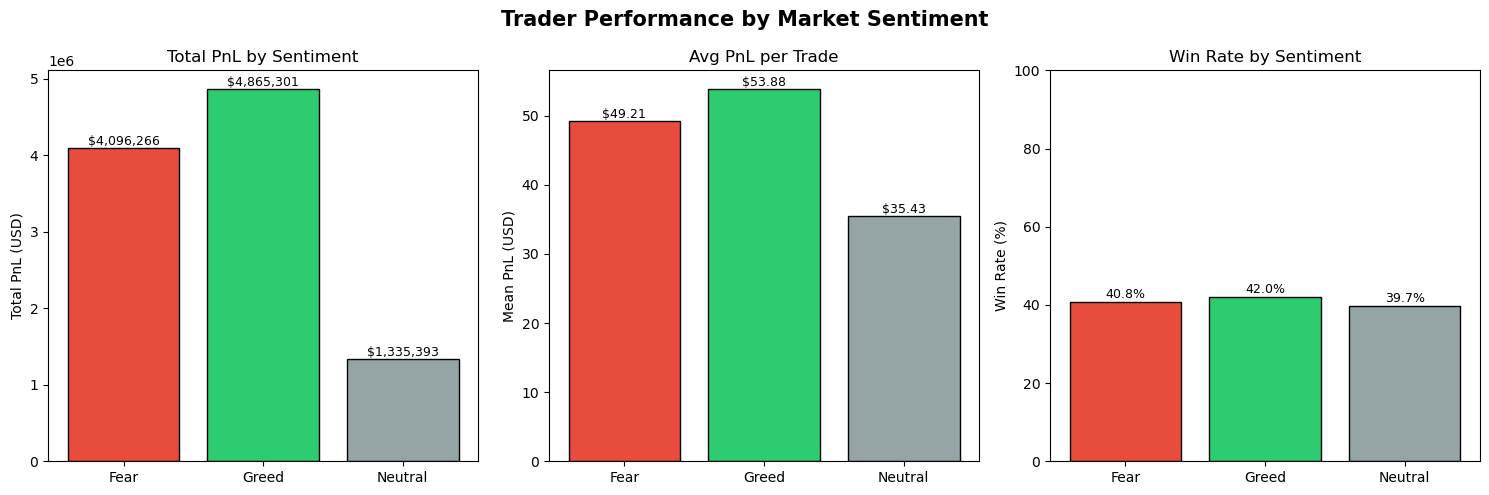

In [7]:
colors = {"Fear": "#E74C3C", "Neutral": "#95A5A6", "Greed": "#2ECC71"}
color_list = [colors.get(s, "gray") for s in summary["sentiment"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Trader Performance by Market Sentiment", fontsize=15, fontweight="bold")

# Total PnL
axes[0].bar(summary["sentiment"], summary["total_pnl"], color=color_list, edgecolor="black")
axes[0].set_title("Total PnL by Sentiment")
axes[0].set_ylabel("Total PnL (USD)")
for i, v in enumerate(summary["total_pnl"]):
    axes[0].text(i, v, f"${v:,.0f}", ha="center", va="bottom" if v>=0 else "top", fontsize=9)

# Mean PnL
axes[1].bar(summary["sentiment"], summary["mean_pnl"], color=color_list, edgecolor="black")
axes[1].set_title("Avg PnL per Trade")
axes[1].set_ylabel("Mean PnL (USD)")
for i, v in enumerate(summary["mean_pnl"]):
    axes[1].text(i, v, f"${v:,.2f}", ha="center", va="bottom" if v>=0 else "top", fontsize=9)

# Win Rate
axes[2].bar(summary["sentiment"], summary["win_rate"]*100, color=color_list, edgecolor="black")
axes[2].set_title("Win Rate by Sentiment")
axes[2].set_ylabel("Win Rate (%)")
axes[2].set_ylim(0, 100)
for i, v in enumerate(summary["win_rate"]):
    axes[2].text(i, v*100+1, f"{v*100:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("chart1_sentiment_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

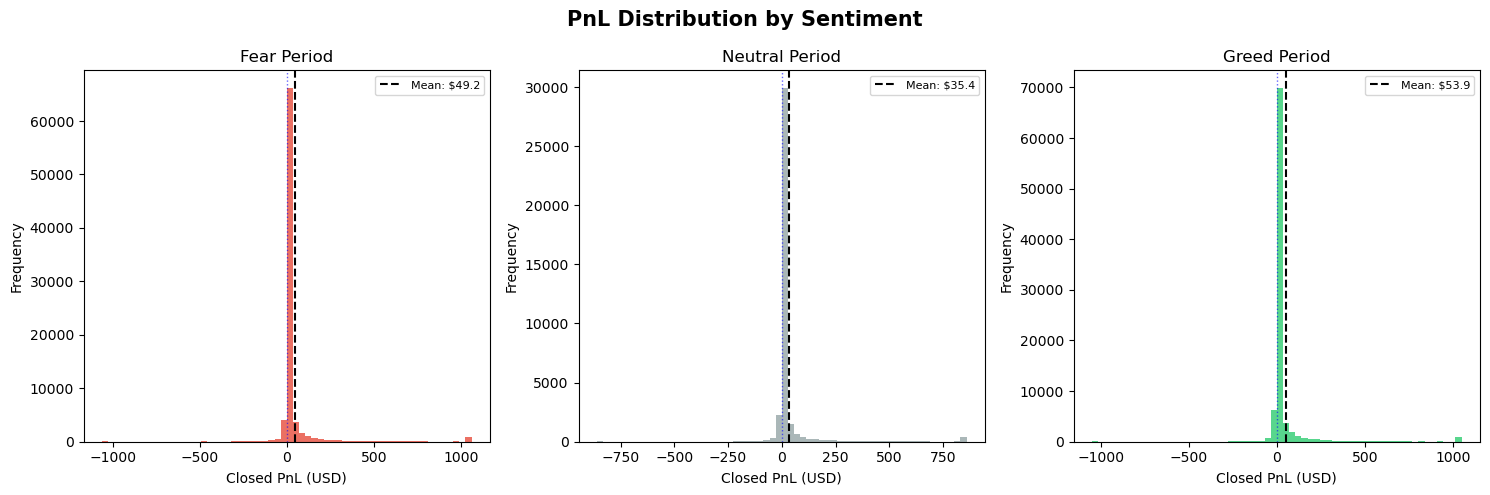

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("PnL Distribution by Sentiment", fontsize=15, fontweight="bold")

for ax, sent, color in zip(axes, ["Fear","Neutral","Greed"], ["#E74C3C","#95A5A6","#2ECC71"]):
    data = merged[merged["sentiment"]==sent]["Closed PnL"]
    # clip extreme outliers for readability
    clip_val = data.quantile(0.99)
    data_clipped = data.clip(-clip_val, clip_val)
    ax.hist(data_clipped, bins=60, color=color, alpha=0.8, edgecolor="none")
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Mean: ${data.mean():.1f}")
    ax.axvline(0, color="blue", linestyle=":", linewidth=1, alpha=0.6)
    ax.set_title(f"{sent} Period")
    ax.set_xlabel("Closed PnL (USD)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("chart2_pnl_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

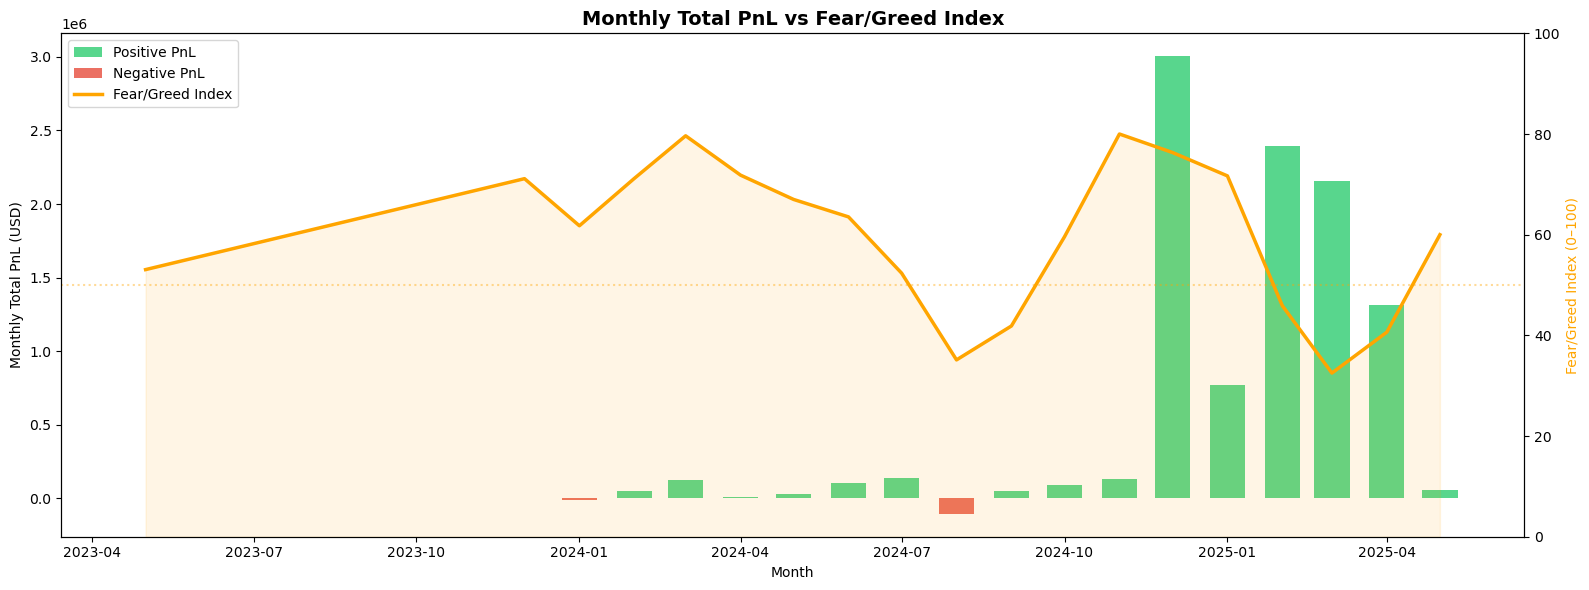

In [9]:
merged["month"] = merged["date"].dt.to_period("M")
fg["month"]     = pd.to_datetime(fg["date"]).dt.to_period("M")

monthly_pnl = merged.groupby("month")["Closed PnL"].sum().reset_index()
monthly_fgi = fg.groupby("month")["value"].mean().reset_index()
monthly     = monthly_pnl.merge(monthly_fgi, on="month")
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

# PnL bars
pos = monthly["Closed PnL"] >= 0
ax1.bar(monthly.loc[pos,  "month_dt"], monthly.loc[pos,  "Closed PnL"], width=20, color="#2ECC71", alpha=0.8, label="Positive PnL")
ax1.bar(monthly.loc[~pos, "month_dt"], monthly.loc[~pos, "Closed PnL"], width=20, color="#E74C3C", alpha=0.8, label="Negative PnL")

# FGI line
ax2.plot(monthly["month_dt"], monthly["value"], color="orange", linewidth=2.5, label="Fear/Greed Index")
ax2.fill_between(monthly["month_dt"], monthly["value"], alpha=0.1, color="orange")
ax2.set_ylim(0, 100)
ax2.set_ylabel("Fear/Greed Index (0–100)", color="orange")
ax2.axhline(50, color="orange", linestyle=":", alpha=0.4)

ax1.set_xlabel("Month")
ax1.set_ylabel("Monthly Total PnL (USD)")
ax1.set_title("Monthly Total PnL vs Fear/Greed Index", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc="upper left")

plt.tight_layout()
plt.savefig("chart3_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

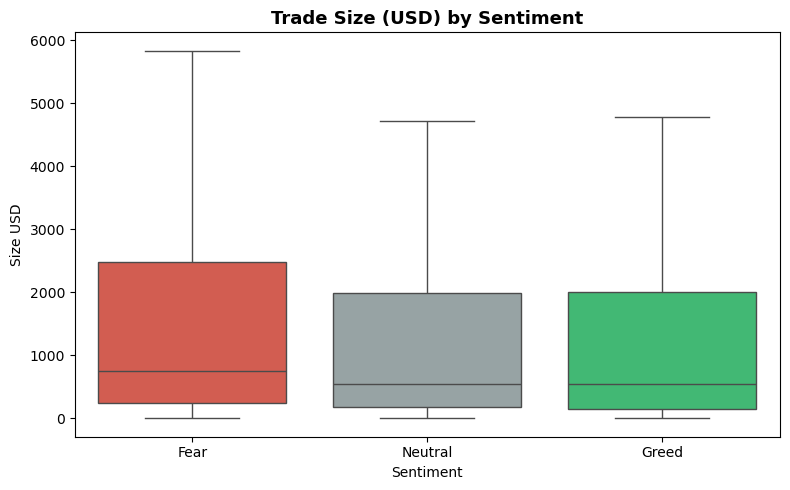

In [10]:
merged["Size USD"] = pd.to_numeric(merged["Size USD"], errors="coerce")

fig, ax = plt.subplots(figsize=(8, 5))
order = ["Fear", "Neutral", "Greed"]
palette = {"Fear":"#E74C3C", "Neutral":"#95A5A6", "Greed":"#2ECC71"}
sns.boxplot(data=merged, x="sentiment", y="Size USD", order=order,
            palette=palette, showfliers=False, ax=ax)
ax.set_title("Trade Size (USD) by Sentiment", fontsize=13, fontweight="bold")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Size USD")
plt.tight_layout()
plt.savefig("chart4_trade_size.png", dpi=150, bbox_inches="tight")
plt.show()

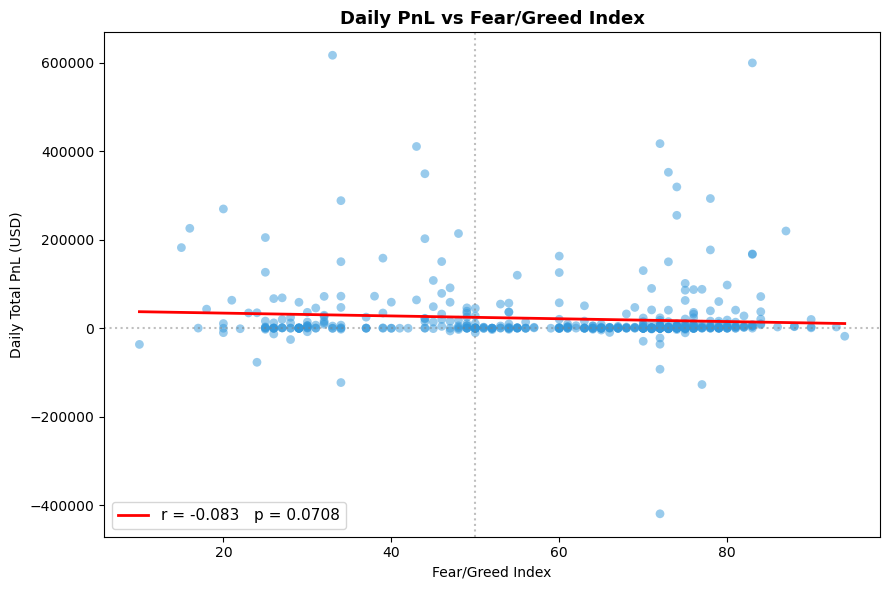

In [11]:
daily_pnl = merged.groupby("date")["Closed PnL"].sum().reset_index()
daily_fgi = fg[["date","value"]].copy()
daily_fgi["date"] = pd.to_datetime(daily_fgi["date"]).dt.normalize()
daily = daily_pnl.merge(daily_fgi, on="date").dropna()

slope, intercept, r, p, _ = stats.linregress(daily["value"], daily["Closed PnL"])
x_line = np.linspace(daily["value"].min(), daily["value"].max(), 100)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(daily["value"], daily["Closed PnL"], alpha=0.5, color="#3498DB", edgecolors="none", s=40)
ax.plot(x_line, slope*x_line+intercept, color="red", linewidth=2,
        label=f"r = {r:.3f}   p = {p:.4f}")
ax.axhline(0,  color="gray", linestyle=":", alpha=0.5)
ax.axvline(50, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Fear/Greed Index")
ax.set_ylabel("Daily Total PnL (USD)")
ax.set_title("Daily PnL vs Fear/Greed Index", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("chart5_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

  Strategy  mean_pnl  win_rate  trade_count
  Momentum  32.12000  0.426661       122240
Contrarian  71.59276  0.390115        88984


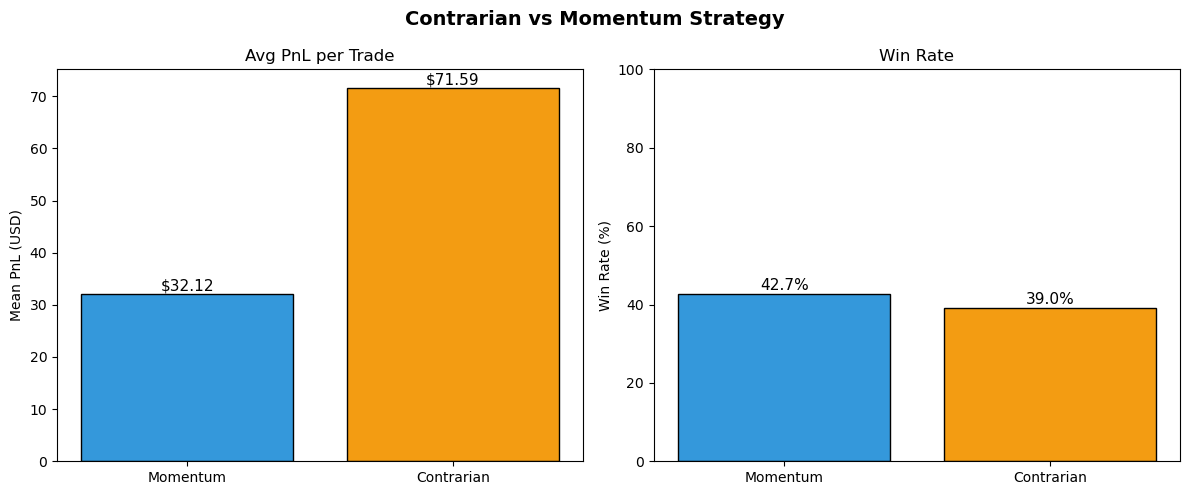

In [12]:
merged["side_upper"]   = merged["Side"].str.upper().str.strip()
merged["is_contrarian"] = (
    ((merged["sentiment"]=="Fear")  & (merged["side_upper"]=="BUY")) |
    ((merged["sentiment"]=="Greed") & (merged["side_upper"]=="SELL"))
)

strategy = merged.groupby("is_contrarian")["Closed PnL"].agg(
    mean_pnl    = "mean",
    win_rate    = lambda x: (x > 0).mean(),
    trade_count = "count"
).reset_index()
strategy["Strategy"] = strategy["is_contrarian"].map({True:"Contrarian", False:"Momentum"})

print(strategy[["Strategy","mean_pnl","win_rate","trade_count"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Contrarian vs Momentum Strategy", fontsize=14, fontweight="bold")

colors = ["#3498DB", "#F39C12"]
axes[0].bar(strategy["Strategy"], strategy["mean_pnl"], color=colors, edgecolor="black")
axes[0].set_title("Avg PnL per Trade")
axes[0].set_ylabel("Mean PnL (USD)")
for i, v in enumerate(strategy["mean_pnl"]):
    axes[0].text(i, v, f"${v:.2f}", ha="center", va="bottom" if v>=0 else "top", fontsize=11)

axes[1].bar(strategy["Strategy"], strategy["win_rate"]*100, color=colors, edgecolor="black")
axes[1].set_title("Win Rate")
axes[1].set_ylabel("Win Rate (%)")
axes[1].set_ylim(0, 100)
for i, v in enumerate(strategy["win_rate"]):
    axes[1].text(i, v*100+1, f"{v*100:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("chart6_contrarian_momentum.png", dpi=150, bbox_inches="tight")
plt.show()

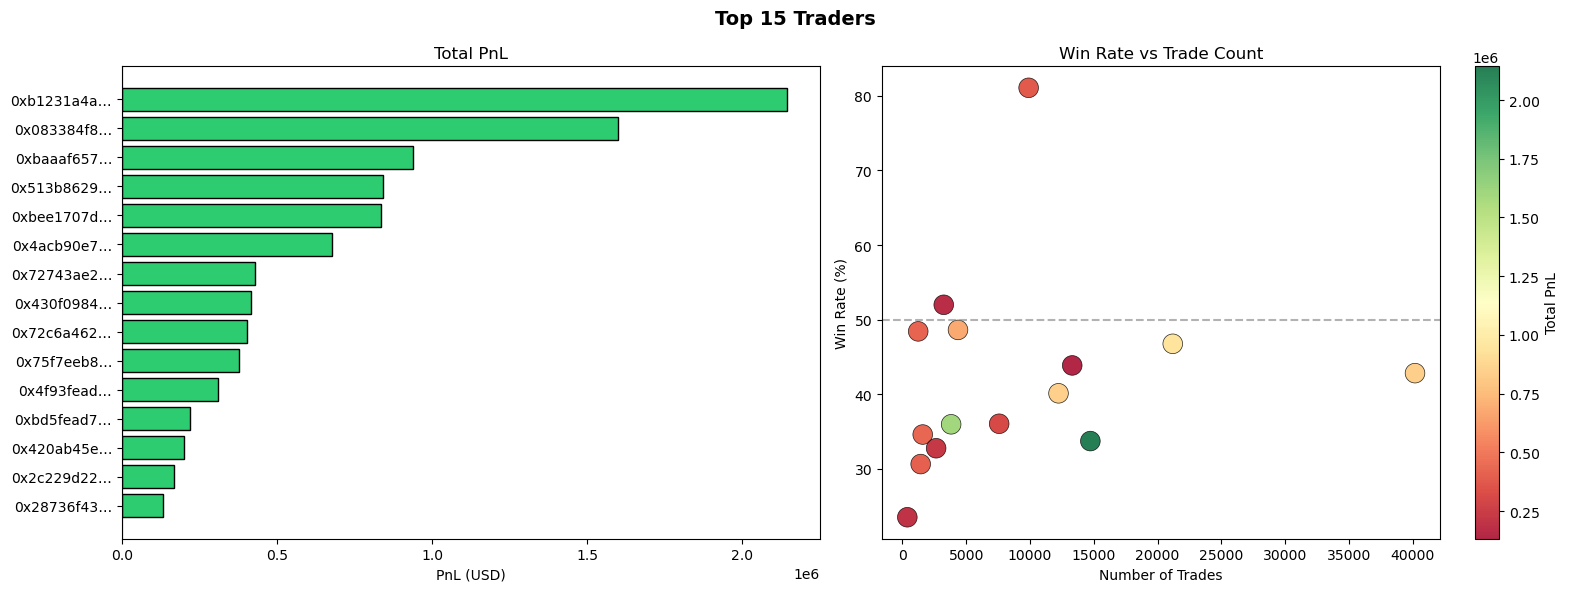

In [13]:
top15 = top_traders.head(15).copy()
labels = [a[:10]+"…" for a in top15["Account"]]
bar_colors = ["#2ECC71" if v >= 0 else "#E74C3C" for v in top15["total_pnl"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top 15 Traders", fontsize=14, fontweight="bold")

axes[0].barh(labels[::-1], top15["total_pnl"].values[::-1], color=bar_colors[::-1], edgecolor="black")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Total PnL")
axes[0].set_xlabel("PnL (USD)")

sc = axes[1].scatter(top15["trade_count"], top15["win_rate"]*100,
                     c=top15["total_pnl"], cmap="RdYlGn",
                     s=200, edgecolors="black", linewidths=0.5, alpha=0.85)
plt.colorbar(sc, ax=axes[1], label="Total PnL")
axes[1].axhline(50, color="gray", linestyle="--", alpha=0.6)
axes[1].set_title("Win Rate vs Trade Count")
axes[1].set_xlabel("Number of Trades")
axes[1].set_ylabel("Win Rate (%)")

plt.tight_layout()
plt.savefig("chart7_top_traders.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
summary.to_csv("summary_sentiment_pnl.csv", index=False)
top_traders.head(50).to_csv("top50_traders.csv", index=False)
strategy[["Strategy","mean_pnl","win_rate","trade_count"]].to_csv("strategy_comparison.csv", index=False)

print("✅ All files saved:")
print("   summary_sentiment_pnl.csv")
print("   top50_traders.csv")
print("   strategy_comparison.csv")
print("   chart1 through chart7 PNGs")

✅ All files saved:
   summary_sentiment_pnl.csv
   top50_traders.csv
   strategy_comparison.csv
   chart1 through chart7 PNGs


In [15]:
print("=== SENTIMENT SUMMARY ===")
print(summary.to_string(index=False))

print("\n=== STATISTICAL TESTS ===")
print(f"Fear  mean PnL : ${fear_pnl.mean():,.2f}")
print(f"Greed mean PnL : ${greed_pnl.mean():,.2f}")
print(f"t-stat: {t_stat:.4f},  p-value: {p_val:.6f}")

print("\n=== STRATEGY COMPARISON ===")
print(strategy[["Strategy","mean_pnl","win_rate","trade_count"]].to_string(index=False))

print("\n=== TOP 5 TRADERS ===")
print(top_traders.head(5).to_string(index=False))

print("\n=== DATASET OVERVIEW ===")
print(f"Total trades     : {len(merged):,}")
print(f"Unique traders   : {merged['Account'].nunique():,}")
print(f"Date range       : {merged['date'].min().date()} to {merged['date'].max().date()}")
print(f"Total PnL        : ${merged['Closed PnL'].sum():,.2f}")
print(f"Overall win rate : {(merged['Closed PnL'] > 0).mean()*100:.1f}%")

=== SENTIMENT SUMMARY ===
sentiment    total_pnl  mean_pnl  median_pnl  trade_count  win_rate
     Fear 4.096266e+06 49.212077         0.0        83237  0.407871
    Greed 4.865301e+06 53.882281         0.0        90295  0.420311
  Neutral 1.335393e+06 35.429074         0.0        37692  0.397087

=== STATISTICAL TESTS ===
Fear  mean PnL : $49.21
Greed mean PnL : $53.88
t-stat: -0.9875,  p-value: 0.323395

=== STRATEGY COMPARISON ===
  Strategy  mean_pnl  win_rate  trade_count
  Momentum  32.12000  0.426661       122240
Contrarian  71.59276  0.390115        88984

=== TOP 5 TRADERS ===
                                   Account    total_pnl   mean_pnl  trade_count  win_rate
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 2.143383e+06 145.481748        14733  0.337134
0x083384f897ee0f19899168e3b1bec365f52a9012 1.600230e+06 419.127768         3818  0.359612
0xbaaaf6571ab7d571043ff1e313a9609a10637864 9.401638e+05  44.364091        21192  0.467582
0x513b8629fe877bb581bf244e326a047b249c4ff1 8.40